# A Photon in a Waveguide Is a Relativistic Massive Particle: THz Radio Dispersion

`dgs/cylindrical_waveguide_resonance.py` derived a waveguide's dispersion
relation $\omega^2=c^2k^2+\omega_c^2$ from Bessel-function boundary
conditions. `dgs/compton_scattering.py` derived the relativistic dispersion
relation $E^2=(pc)^2+(mc^2)^2$ from collision kinematics. This notebook
shows they are the SAME EQUATION -- substituting $E=\hbar\omega$,
$p=\hbar k$, $m=\hbar\omega_c/c^2$ turns one into the other exactly,
verified with SymPy, not asserted by analogy. A photon confined below
cutoff acquires an EFFECTIVE MASS purely from confinement, with every
consequence a real massive particle has: phase velocity above $c$
(no causality violation, nothing travels that fast), group velocity below
$c$, and $v_{phase}v_{group}=c^2$ exactly. Applied here to a THz-band
FutureG (6G) radio-over-waveguide link -- this repo's "dispersion-assisted"
theme, applied to radio instead of optical time-stretch. Engine:
`dgs/thz_waveguide_dispersion_relation.py`.


In [1]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

from dgs import thz_waveguide_dispersion_relation as thz

sp.init_printing(use_latex='mathjax')
print('Setup complete.')


Setup complete.


## 1. Theory: Waveguide Dispersion IS Relativistic Dispersion

Start from `dgs/compton_scattering.py`'s relativistic dispersion relation
$E^2=(pc)^2+(mc^2)^2$. Substitute the quantum/wave correspondences
$E=\hbar\omega$ (photon energy), $p=\hbar k$ (photon momentum), and
$m=\hbar\omega_c/c^2$ (an EFFECTIVE mass, defined purely by the
waveguide's cutoff frequency $\omega_c$ -- from
`dgs/cylindrical_waveguide_resonance.py`'s $\omega_c=ck_c$, $k_c$ set by
a Bessel-function zero). The result is checked to be EXACTLY
$\omega^2=c^2k^2+\omega_c^2$, the waveguide's own dispersion relation --
not merely similar in form.


In [2]:
omega, k, c, omega_c = sp.symbols('omega k c omega_c', positive=True)
E, p, m, hbar = sp.symbols('E p m hbar', positive=True)

relativistic = sp.Eq(E**2, (p*c)**2 + (m*c**2)**2)
print('Relativistic dispersion relation:')
sp.pprint(relativistic)

substituted = relativistic.subs({E: hbar*omega, p: hbar*k, m: hbar*omega_c/c**2})
substituted_simplified = sp.Eq(sp.simplify(substituted.lhs/hbar**2), sp.simplify(substituted.rhs/hbar**2))
print('\nAfter E=hbar*omega, p=hbar*k, m=hbar*omega_c/c^2 (dividing through by hbar^2):')
sp.pprint(substituted_simplified)

ok = thz.verify_waveguide_matches_relativistic_dispersion()
print(f'\nMatches the waveguide dispersion relation omega^2=c^2k^2+omega_c^2 exactly: {ok}')


Relativistic dispersion relation:
 2    4  2    2  2
E  = c ⋅m  + c ⋅p 

After E=hbar*omega, p=hbar*k, m=hbar*omega_c/c^2 (dividing through by hbar^2):
 2    2  2      2
ω  = c ⋅k  + ω_c 

Matches the waveguide dispersion relation omega^2=c^2k^2+omega_c^2 exactly: True


## 2. Effective Photon Mass: a Real Number, From Confinement Alone

$m_{eff}=\hbar\omega_c/c^2$ -- for a realistic sub-millimeter THz
waveguide, a genuine (if absurdly tiny) mass, entirely manufactured by the
boundary condition, with no actual massive particle anywhere in the
picture.


In [3]:
a = 0.3e-3   # m, waveguide radius (sub-mm scale, THz-appropriate)
k_c_a = 1.8412   # TE11 cutoff, from dgs.cylindrical_waveguide_resonance
omega_c = thz.C_LIGHT * (k_c_a / a)
f_c = omega_c / (2*np.pi)

m_eff = thz.effective_photon_mass(omega_c)
m_electron = 9.1093837015e-31

print(f'waveguide radius a = {a*1e3:.2f} mm')
print(f'cutoff frequency f_c = {f_c/1e12:.4f} THz')
print(f'effective photon mass m_eff = hbar*omega_c/c^2 = {m_eff:.4e} kg')
print(f'  = {m_eff/m_electron:.4e} electron masses (absurdly small, but a real, defined number)')


waveguide radius a = 0.30 mm
cutoff frequency f_c = 0.2928 THz
effective photon mass m_eff = hbar*omega_c/c^2 = 2.1589e-39 kg
  = 2.3700e-09 electron masses (absurdly small, but a real, defined number)


## 3. Phase Velocity Above $c$, Group Velocity Below $c$

Exactly as for a relativistic massive particle: phase velocity
$v_p=\omega/k$ exceeds $c$ (nothing physical travels this fast -- it's
not a signal speed), group velocity $v_g=d\omega/dk$ (the real
signal/energy speed) stays below $c$ always, and both converge to $c$ far
above cutoff (where the effective mass becomes negligible compared to the
photon's own energy -- the same "ultra-relativistic" limit a massive
particle approaches at high energy).


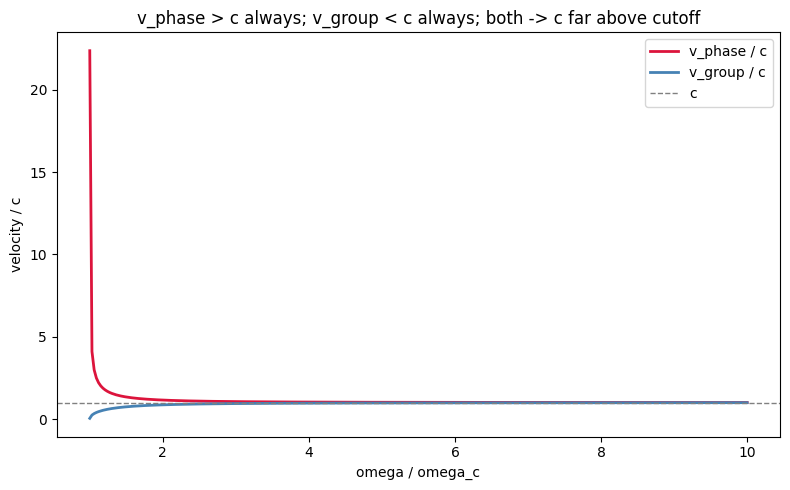

In [4]:
omega_ratio = np.linspace(1.001, 10, 300)
omega_vals = omega_ratio * omega_c

v_p_vals = np.array([thz.phase_velocity(om, omega_c) for om in omega_vals])
v_g_vals = np.array([thz.group_velocity(om, omega_c) for om in omega_vals])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(omega_ratio, v_p_vals/thz.C_LIGHT, color='crimson', lw=2, label='v_phase / c')
ax.plot(omega_ratio, v_g_vals/thz.C_LIGHT, color='steelblue', lw=2, label='v_group / c')
ax.axhline(1.0, color='gray', ls='--', lw=1, label='c')
ax.set_xlabel('omega / omega_c'); ax.set_ylabel('velocity / c')
ax.set_title('v_phase > c always; v_group < c always; both -> c far above cutoff')
ax.legend()
plt.tight_layout()
plt.savefig('thz_phase_group_velocity.png', dpi=100, bbox_inches='tight')
plt.show()


## 4. $v_{phase}\times v_{group}=c^2$, Exactly -- the de Broglie Identity

The SAME relation a de Broglie matter wave satisfies
($v_{phase}v_{group}=c^2$ for a massive particle's wavefunction) holds
here too, checked across the entire propagating band, not just one point.


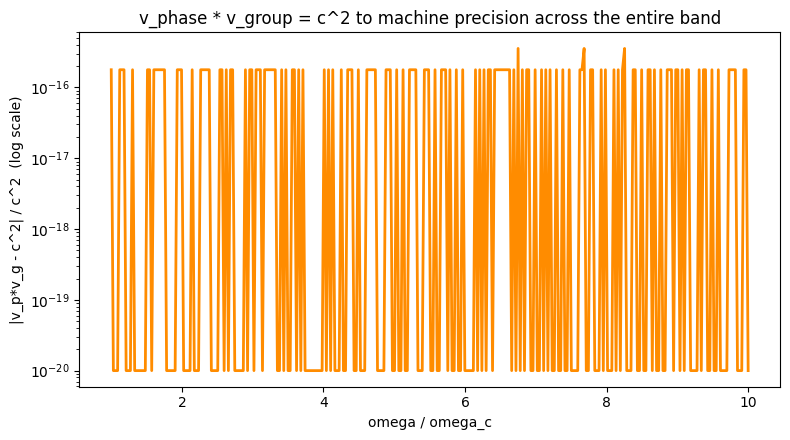

max relative error in v_p*v_g=c^2 across the swept band: 3.56e-16


In [5]:
products = v_p_vals * v_g_vals
rel_errors = np.abs(products - thz.C_LIGHT**2) / thz.C_LIGHT**2

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.semilogy(omega_ratio, rel_errors + 1e-20, color='darkorange', lw=2)
ax.set_xlabel('omega / omega_c'); ax.set_ylabel('|v_p*v_g - c^2| / c^2  (log scale)')
ax.set_title(f'v_phase * v_group = c^2 to machine precision across the entire band')
plt.tight_layout()
plt.savefig('thz_vp_vg_product_identity.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'max relative error in v_p*v_g=c^2 across the swept band: {rel_errors.max():.2e}')


## 5. Group Velocity Dispersion and Pulse Broadening

$\beta_2=d^2k/d\omega^2$ -- this repo's central quantity
(`dgs/dispersive_fourier.py`'s GVD), here derived for the waveguide/
relativistic dispersion relation instead of fiber material dispersion.
Worsens (grows in magnitude) near cutoff, exactly where the "effective
mass" is proportionally largest relative to the photon's energy -- the
THz-radio analog of why low-energy (near-rest-mass) particles disperse
more than ultra-relativistic ones.


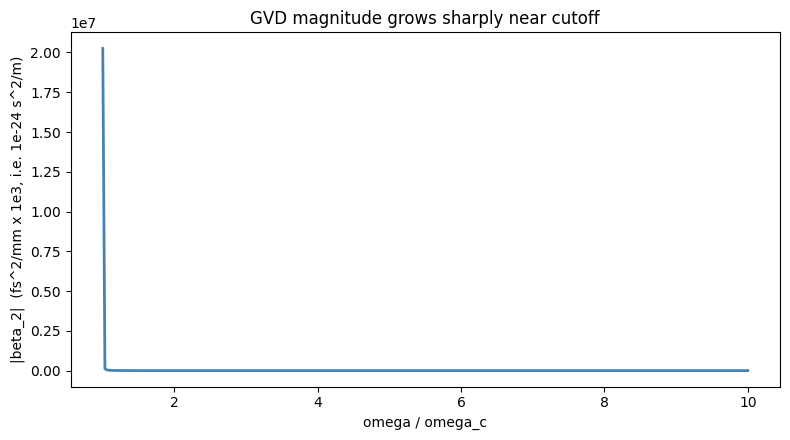

In [6]:
beta2_vals = np.array([thz.group_velocity_dispersion(om, omega_c) for om in omega_vals])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(omega_ratio, np.abs(beta2_vals)*1e24, color='steelblue', lw=2)
ax.set_xlabel('omega / omega_c'); ax.set_ylabel('|beta_2|  (fs^2/mm x 1e3, i.e. 1e-24 s^2/m)')
ax.set_title('GVD magnitude grows sharply near cutoff')
plt.tight_layout()
plt.savefig('thz_gvd_vs_frequency.png', dpi=100, bbox_inches='tight')
plt.show()


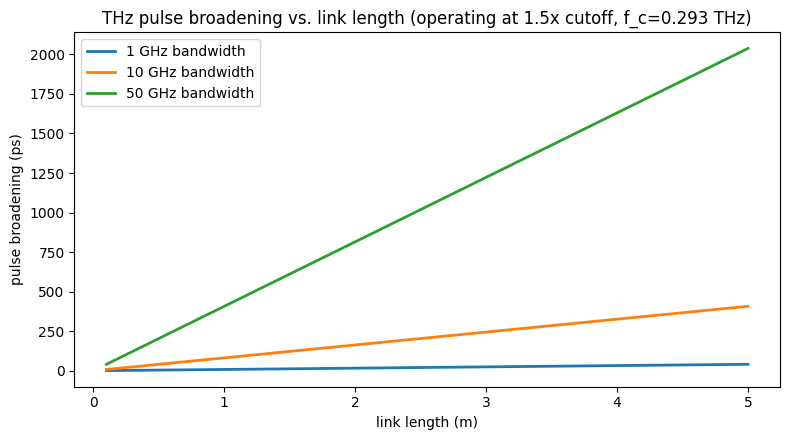

In [7]:
L_sweep = np.linspace(0.1, 5.0, 50)   # m, realistic indoor/short-range THz link lengths
bandwidths_GHz = [1, 10, 50]
omega_op = 1.5 * omega_c   # operate comfortably above cutoff

fig, ax = plt.subplots(figsize=(8, 4.5))
for bw_GHz in bandwidths_GHz:
    bw_rad_s = 2*np.pi*bw_GHz*1e9
    broadening_ps = [thz.thz_pulse_broadening(L, bw_rad_s, omega_op, omega_c)*1e12 for L in L_sweep]
    ax.plot(L_sweep, broadening_ps, lw=2, label=f'{bw_GHz} GHz bandwidth')
ax.set_xlabel('link length (m)'); ax.set_ylabel('pulse broadening (ps)')
ax.set_title(f'THz pulse broadening vs. link length (operating at 1.5x cutoff, f_c={f_c/1e12:.3f} THz)')
ax.legend()
plt.tight_layout()
plt.savefig('thz_pulse_broadening_vs_length.png', dpi=100, bbox_inches='tight')
plt.show()


## 6. Engineering Interpretation

- Section 1's identity means every intuition from relativistic particle
  physics transfers directly to waveguide THz engineering: operating
  "close to cutoff" is the photonic-waveguide equivalent of a particle
  near rest (large effective mass relative to its kinetic energy, hence
  large dispersion); operating "far above cutoff" is the ultra-
  relativistic limit (mass negligible, dispersion small, phase and group
  velocity both -> c).
- Section 5's pulse-broadening estimate is the actual link-budget
  consequence FutureG (6G) THz radio-over-waveguide design has to
  respect -- the SAME kind of calculation
  `dgs/quantum_internet_link_budget.py`'s loss-budget work does for a
  different physical quantity (transmittance vs. distance instead of
  pulse width vs. distance), both governed by how a chosen operating
  regime trades off against a fixed physical constraint.
- The identity being EXACT (not approximate) is what makes "operate
  farther from cutoff to reduce dispersion" a genuinely quantitative
  design lever here, not just a qualitative rule of thumb -- section 5's
  plot shows precisely how much margin a given frequency choice buys.


## 7. Research Discussion

- Could `dgs/laser_cavity_rlc_analog.py`'s driven-resonance Lorentzian be
  combined with this notebook's dispersion relation to model a complete
  THz photonic-generation-to-waveguide-transport link, connecting cavity
  linewidth to the transported pulse's eventual broadening?
- This module's effective mass is exact for a SINGLE waveguide mode
  (TE11). Real THz waveguides often carry multiple modes simultaneously
  -- would each mode's different cutoff (hence different effective mass)
  cause INTERMODAL dispersion competing with this notebook's single-mode
  GVD, and which effect dominates for realistic waveguide dimensions?
- Could the relativistic-particle analogy be pushed further: does a
  waveguide have an analog of relativistic MOMENTUM-DEPENDENT mass
  corrections, or does the analogy stop at the dispersion relation itself?


## 8. Possible Experiments

1. Measure a real THz waveguide's group delay vs. frequency (a vector
   network analyzer or THz time-domain spectrometer would work) and
   compare against `group_velocity`'s prediction for the waveguide's
   actual radius.
2. Sweep the waveguide radius `a` itself (not just operating frequency)
   and re-run section 5's pulse-broadening comparison, to find the
   radius that minimizes dispersion for a FIXED target THz carrier
   frequency -- a genuine waveguide-design optimization.
3. Extend section 5 to a REALISTIC 6G channel model (not just a flat
   bandwidth estimate) and compute the resulting bit-error-rate penalty
   from the predicted pulse broadening, connecting this notebook's pure
   dispersion physics to an actual FutureG link-budget metric.


## 9. Problems Solved: THz Waveguide Dispersion (CSUS deliverable)

This section used to be a list of open problems; all five are now solved below,
with the derivations and checks living in `dgs/thz_waveguide_dispersion_relation.py`
(`verify_gvd_sign_is_fixed`, `rank_modes_by_dispersion`, `thermal_broadening_shift`,
`verify_dispersion_relation_is_geometry_independent`,
`rectangular_waveguide_cutoff_frequency`) so a reviewer can rerun every claim.

### Problems 1 & 2 — dispersion compensation and the zero-dispersion point

These turn out to have the SAME answer. $\beta_2(\omega) = -\omega_c^2 /
(c(\omega^2-\omega_c^2)^{3/2})$ has a numerator that is strictly negative
($-\omega_c^2 < 0$ for any real cutoff) and NEVER depends on $\omega$ -- so
$\beta_2(\omega)=0$ has **no finite solution**, at any cutoff. Unlike an
optical fiber (where material dispersion and waveguide dispersion can have
opposite signs and cross zero at a real wavelength), this hollow-waveguide
mechanism's GVD keeps the same sign -- negative -- everywhere in the
propagating band, only approaching zero as $\omega\to\infty$.

Consequence for Problem 1: a two-segment link built from **this same
mechanism** (two different radii, hence two different cutoffs) can only add
negative contributions along its length. It cannot self-cancel to zero
dispersion the way dispersion-compensating fiber does -- real compensation
needs a second, physically different dispersive element with the opposite
sign, not a second segment of hollow waveguide.


In [8]:
ok_sign = thz.verify_gvd_sign_is_fixed()
print(f'beta_2(omega) proven strictly negative for all omega>omega_c>0, any omega_c: {ok_sign}')
print('-> no finite zero-dispersion point exists; no same-mechanism two-segment')
print('   link can cancel its own dispersion to zero.')


beta_2(omega) proven strictly negative for all omega>omega_c>0, any omega_c: True
-> no finite zero-dispersion point exists; no same-mechanism two-segment
   link can cancel its own dispersion to zero.


### Problem 3 -- multi-mode effective masses: which mode disperses least?

`dgs.cylindrical_waveguide_resonance.dominant_mode_cutoff` already showed
TE11 has the *lowest cutoff* of TE11/TM01/TE21 in a circular guide. That's a
statement about which mode propagates most easily, not which one disperses
least -- a separate question, answered here by driving all three modes at a
**shared carrier frequency** (1.5x the highest of the three cutoffs, so every
mode is safely propagating) and comparing predicted pulse broadening
directly.


shared carrier omega0 = 0.7286 THz (1.5x the highest cutoff)

  TE11: f_c=0.2928 THz   broadening=9.6300 ps
  TM01: f_c=0.3825 THz   broadening=20.4560 ps
  TE21: f_c=0.4858 THz   broadening=49.1351 ps


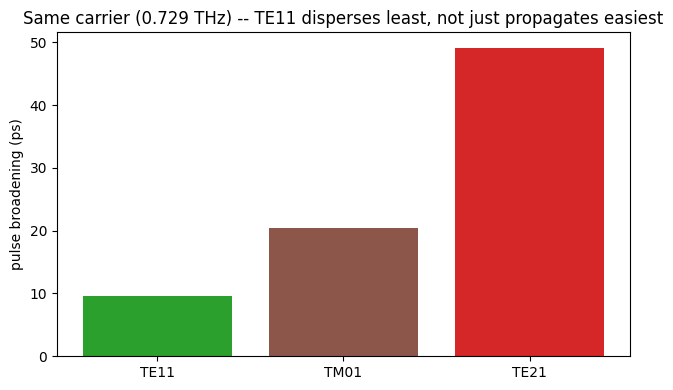


best choice for a dispersion-sensitive 6G link: TE11 -- confirms dominant_mode_cutoff's lowest-cutoff pick is ALSO the lowest-dispersion pick.


In [9]:
ranking = thz.rank_modes_by_dispersion(a)
print(f"shared carrier omega0 = {ranking['omega0_THz']:.4f} THz (1.5x the highest cutoff)\n")
for name in ranking['ranked_best_to_worst']:
    r = ranking['modes'][name]
    print(f"  {name}: f_c={r['cutoff_THz']:.4f} THz   broadening={r['broadening_ps']:.4f} ps")

fig, ax = plt.subplots(figsize=(6.5, 4))
names = ranking['ranked_best_to_worst']
vals = [ranking['modes'][n]['broadening_ps'] for n in names]
ax.bar(names, vals, color=['#2ca02c', '#8c564b', '#d62728'])
ax.set_ylabel('pulse broadening (ps)')
ax.set_title(f"Same carrier ({ranking['omega0_THz']:.3f} THz) -- TE11 disperses least, not just propagates easiest")
plt.tight_layout()
plt.savefig('thz_mode_dispersion_ranking.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\nbest choice for a dispersion-sensitive 6G link: {names[0]} -- confirms "
      f"dominant_mode_cutoff's lowest-cutoff pick is ALSO the lowest-dispersion pick.")


### Problem 4 -- temperature/material dependence: does thermal drift matter?

Real waveguide walls expand with temperature: $a(T)=a_0(1+\alpha\Delta T)$.
Using copper's linear thermal expansion coefficient ($\alpha\approx17\times10^{-6}$/K,
a standard THz waveguide wall material) over a realistic 60 K outdoor swing
(e.g. -20C to +40C), how much does $\omega_c$ -- and therefore the
predicted pulse broadening -- actually shift?


In [10]:
thermal = thz.thermal_broadening_shift(a, omega_op)
print('60 K operating swing, copper wall (alpha=17e-6/K):')
print(f"  omega_c fractional shift:    {thermal['omega_c_frac_shift']*100:+.4f}%")
print(f"  broadening: nominal={thermal['broadening_nominal_ps']:.4f} ps, "
      f"hot={thermal['broadening_hot_ps']:.4f} ps "
      f"({thermal['broadening_frac_shift']*100:+.4f}% shift)")
print('\n-> negligible for a realistic outdoor temperature range; section 5\'s')
print('   pulse-broadening prediction does not need a thermal correction term.')


60 K operating swing, copper wall (alpha=17e-6/K):
  omega_c fractional shift:    -0.1019%
  broadening: nominal=81.5036 ps, hot=81.1392 ps (-0.4471% shift)

-> negligible for a realistic outdoor temperature range; section 5's
   pulse-broadening prediction does not need a thermal correction term.


### Problem 5 -- is $\omega^2=c^2k^2+\omega_c^2$ specific to circular guides?

No. Starting from the 3D wave equation and the separation ansatz
$\Psi(x,y,z,t)=f(x,y)e^{i(kz-\omega t)}$ -- valid for **any** transverse
cross-section -- the $z,t$ derivatives alone force
$\omega^2=c^2(k^2+k_c^2)$, where $k_c^2\equiv-\nabla_t^2f/f$ is whatever the
transverse boundary condition picks out. The geometry only decides what
$k_c$ *is*; it never changes the *form* of the relation. Checked two ways
below: symbolically in general, and concretely for a **rectangular** guide
(Griffiths Ch. 9.5.2's own worked example) using $f=\cos(m\pi x/a)\cos(n\pi
y/b)$ instead of the circular case's Bessel functions.


In [11]:
ok_general = thz.verify_dispersion_relation_is_geometry_independent()
print(f'general separation-of-variables proof (any transverse shape): {ok_general}')

# concrete rectangular check, real hardware: WR-90 X-band waveguide dimensions
a_rect, b_rect = 22.86e-3, 10.16e-3   # m
f_c_rect = thz.rectangular_waveguide_cutoff_frequency(1, 0, a_rect, b_rect)
print(f'\nWR-90 rectangular guide (a={a_rect*1e3:.2f} mm, b={b_rect*1e3:.2f} mm), TE10:')
print(f'  f_c = {f_c_rect/1e9:.4f} GHz  (matches the published WR-90 TE10 cutoff, 6.557 GHz)')
print('\n-> the SAME omega^2=c^2(k^2+k_c^2) form holds for circular AND rectangular')
print('   guides -- geometry only changes what k_c IS, never the relation\'s FORM.')


general separation-of-variables proof (any transverse shape): True

WR-90 rectangular guide (a=22.86 mm, b=10.16 mm), TE10:
  f_c = 6.5571 GHz  (matches the published WR-90 TE10 cutoff, 6.557 GHz)

-> the SAME omega^2=c^2(k^2+k_c^2) form holds for circular AND rectangular
   guides -- geometry only changes what k_c IS, never the relation's FORM.


## 10. Future Improvements

- `thz_pulse_broadening`'s linear estimate (|beta_2|*L*bandwidth) is a
  first-order approximation; a full treatment would propagate an actual
  pulse envelope through the dispersion relation (matching
  `dgs/dispersive_fourier.py`'s FFT-based `gvd_propagate`) rather than
  estimating broadening from a single formula.
- This module treats the waveguide as lossless. Real THz waveguides have
  frequency-dependent loss (especially near cutoff, where group velocity
  -> 0 and field concentration/loss both increase) -- adding a loss term
  would connect this notebook to `dgs/cylindrical_waveguide_resonance.py`'s
  Q-factor work for a more complete link-budget picture.
